# Homework 7
This homework is going to give you experience with LSTM models and additional insight into some of the tools stock traders use to predict when to buy and sell stocks.

Read the file SPY.csv which has the market data for the S&P 500 index fund.  Convert the 'Date' column to pandas datetime datetime and drop all the other columns except for "Adj Close".

Print the first 5 rows of the dataframe and then plot the Adjusted Close price vs date with a title and proper labels on the x-axis.

In [ ]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense

plt.style.use("seaborn-v0_8")


# Read the SPY data
df = pd.read_csv("SPY.csv")

# Show first 5 rows
print(df.head())

/Users/magmac/Downloads/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


         Date        Open        High         Low       Close   Adj Close  \
0  2023-03-13  381.809998  390.390015  380.649994  385.359985  379.590698   
1  2023-03-14  390.500000  393.450012  387.049988  391.730011  385.865387   
2  2023-03-15  385.890015  389.489990  383.709991  389.279999  383.452057   
3  2023-03-16  386.820007  396.470001  386.290009  396.109985  390.179749   
4  2023-03-17  393.220001  394.399994  388.549988  389.989990  385.617523   

      Volume  
0  157790000  
1  149752400  
2  172996900  
3  143254200  
4  140553400  


# Part a

Make the 'Date' column into pandas datetime with .to_datetime() and make that column the index of the dataframe.  Plot the Adj Close price vs date.  Make sure the x-axis is labeled 'Date' and the year-month is labeling the tic marks.  Do not let the plot have numbers from zero to 365 for the x-axis.  Put a title on your plot as shown below:
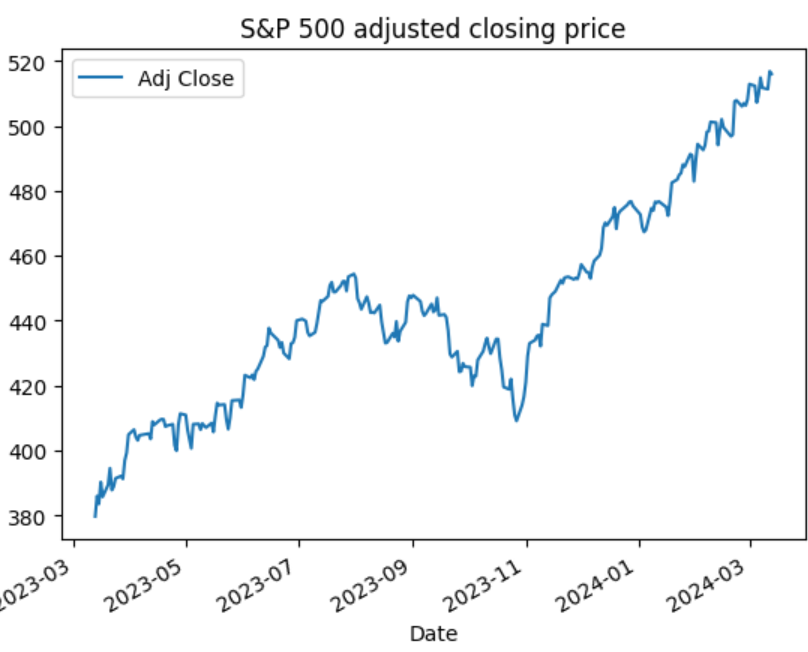

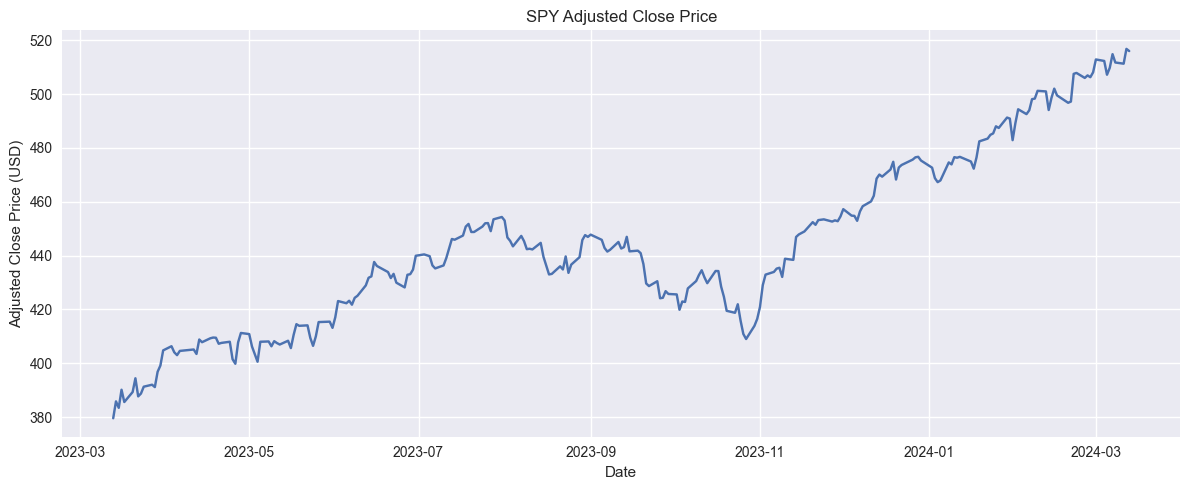

In [3]:
# Convert Date to datetime and make it the index
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

# Keep only the Adjusted Close column
df = df[["Adj Close"]]

# Plot Adjusted Close vs Date
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Adj Close"])
plt.title("SPY Adjusted Close Price")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price (USD)")
plt.tight_layout()
plt.show()

# Part b
## Scale the data to range 0 to 1
Use the MinMaxScaler from sklearn to scale the adjusted closing price.
Plot the scaled closing price just to be sure the curve has the same shape.  Call the output of the scaler 'train'

Don't worry about the axis labels, just plot the numpy array.
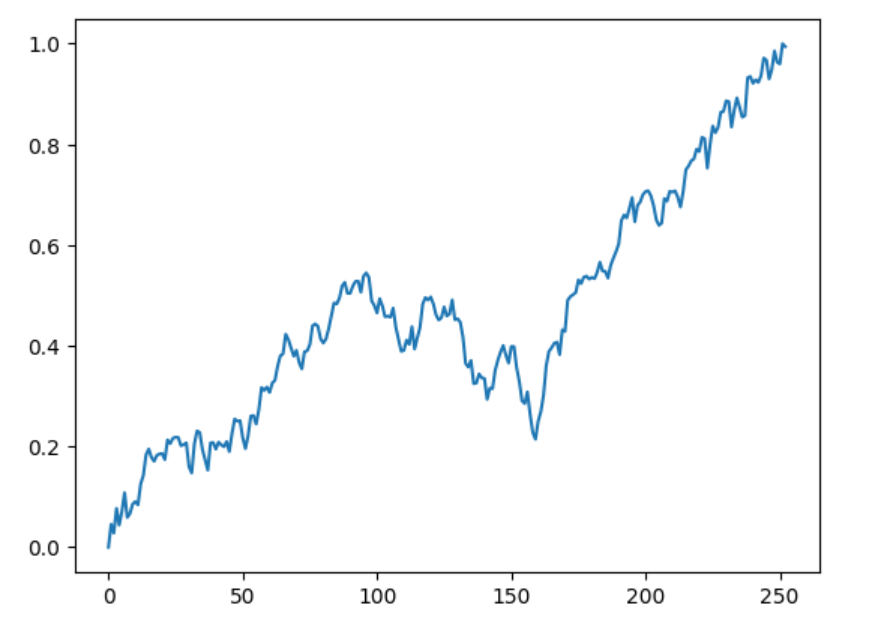

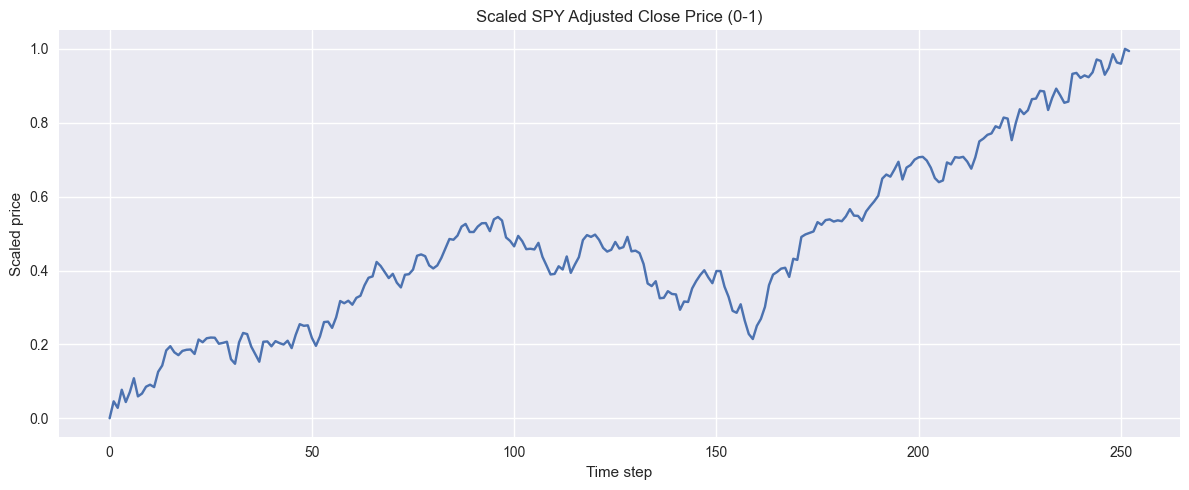

In [4]:
# Scale Adj Close to [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))

# Scale only the Adj Close column
train = scaler.fit_transform(df[["Adj Close"]].values)

# Quick sanity check: plot the scaled series
plt.figure(figsize=(12, 5))
plt.plot(train)
plt.title("Scaled SPY Adjusted Close Price (0-1)")
plt.xlabel("Time step")
plt.ylabel("Scaled price")
plt.tight_layout()
plt.show()

## Incorporating Timesteps Into Data
We should input our data in the form of a 3D array to the LSTM model. First, we create data in 10 timesteps before using numpy to convert it into an array. Finally, we convert the data into a 3D array with X_train samples, 10 timestamps, and one feature at each step.

Each row of data has ten days of data.  Each successive row is the previous row, shifted by one day.

Use the following code to create your X_train and y_train arrays

In [5]:
X_train = []
y_train = []
for i in range(10, len(train)):
    X_train.append(train[i-10:i, 0])
    y_train.append(train[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [6]:
X_train[:5]

array([[[0.        ],
        [0.04573744],
        [0.0281462 ],
        [0.07718567],
        [0.04393071],
        [0.07095867],
        [0.10822148],
        [0.05921049],
        [0.06685048],
        [0.08544563]],

       [[0.04573744],
        [0.0281462 ],
        [0.07718567],
        [0.04393071],
        [0.07095867],
        [0.10822148],
        [0.05921049],
        [0.06685048],
        [0.08544563],
        [0.09077928]],

       [[0.0281462 ],
        [0.07718567],
        [0.04393071],
        [0.07095867],
        [0.10822148],
        [0.05921049],
        [0.06685048],
        [0.08544563],
        [0.09077928],
        [0.08436475]],

       [[0.07718567],
        [0.04393071],
        [0.07095867],
        [0.10822148],
        [0.05921049],
        [0.06685048],
        [0.08544563],
        [0.09077928],
        [0.08436475],
        [0.1258076 ]],

       [[0.04393071],
        [0.07095867],
        [0.10822148],
        [0.05921049],
        [0.06685048],
  

# Part c
Using Keras Sequential, create an LSTM model that has the following:
LSTM layer with 50 units, return_sequences=True

Dropout layer with 0.2 dropout

LSTM layer with 50 units, return_sequences=True

Dropout layer with 0.2 dropout

LSTM layer with 50 units, return_sequences=True

Dropout layer with 0.2 dropout

LSTM layer with 50 units

Dropout layer with 0.2 dropout

Dense layer with one unit

Compile with 'adam' optimizer and loss='mean_squared_error' and fit with 100 epochs and batch_size 32.

The model summary should look like this:

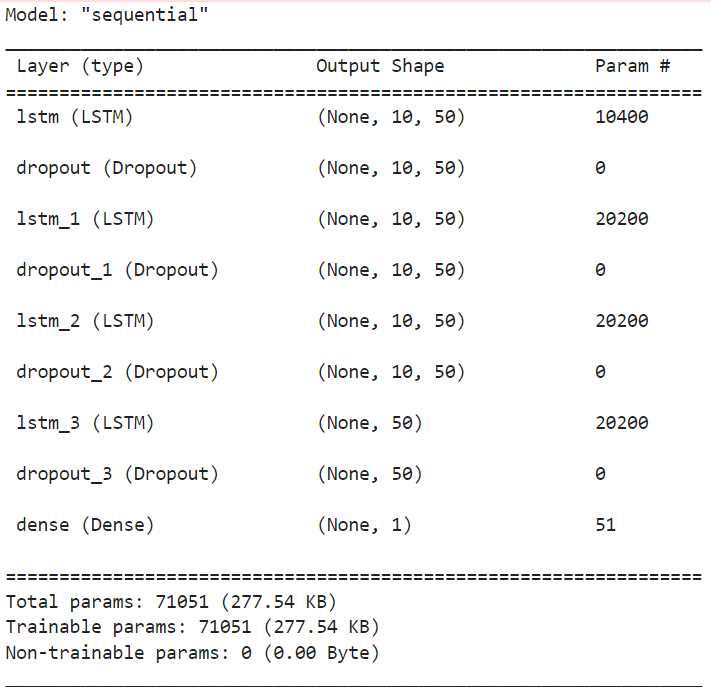

In [ ]:
# 4-layer LSTM model with dropout
model = Sequential()
model.add(
    LSTM(
        50,
        return_sequences=True,
        input_shape=(X_train.shape[1], 1)
    )
)
model.add(Dropout(0.2))

model.add(LSTM(50, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(50, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(50))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer="adam", loss="mean_squared_error")

model.summary()

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    verbose=1
)

2025-11-05 23:40:04.575573: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2025-11-05 23:40:04.575596: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2025-11-05 23:40:04.575599: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2025-11-05 23:40:04.575613: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-05 23:40:04.575622: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/Users/magmac/Downloads/.venv/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequentia

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 10, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100


2025-11-05 23:40:05.761693: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 132ms/step - loss: 0.2087
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0248
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0229
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0203
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0133
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0100
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0055
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0057
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0065
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0073
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0070
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0061
Epoch 13/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0056
Epoch 14/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0067
Epoch 15/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0058
Epoch 16/100
8/8 ━━━━━━━━━━━━━

### Plot the loss vs epochs for the model

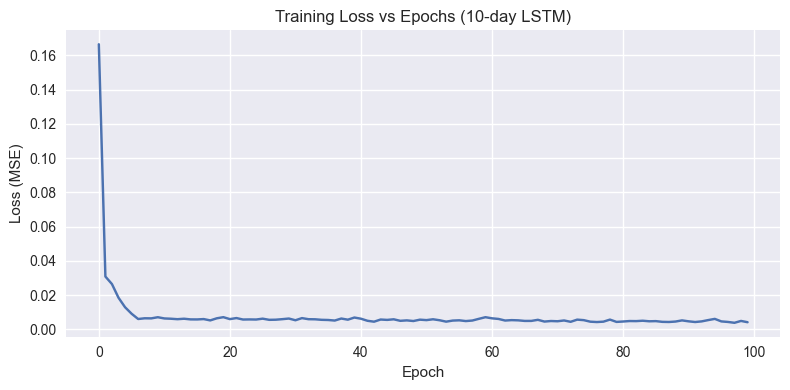

In [ ]:
# Training loss vs epochs for 10-day model
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"])
plt.title("Training Loss vs Epochs (10-day LSTM)")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.tight_layout()
plt.show()

# Part d

Use model.predict to predict the stock price using X_train as input.  This will predict each day using the past ten days of X_train data in each row.  Then use the scaler inverse transform method to turn the predictions into the actual dollar amounts.

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


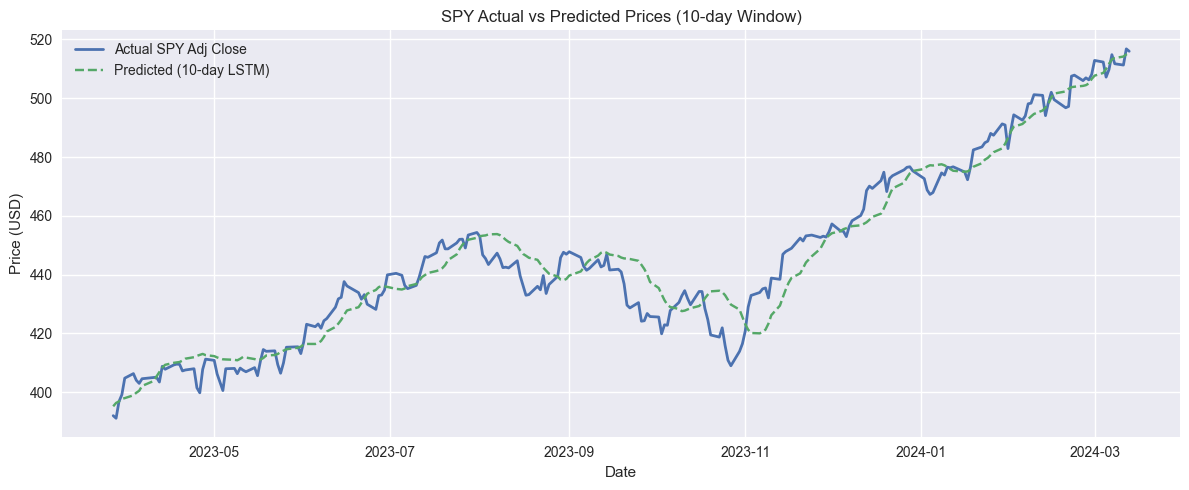

In [9]:
# Predict with 10-day model and plot vs actual
predicted_10_scaled = model.predict(X_train)

# Inverse transform to dollar values
predicted_10 = scaler.inverse_transform(predicted_10_scaled)

# Align predicted prices with the corresponding dates/actuals
dates_10 = df.index[10:]
actual_10 = df["Adj Close"].iloc[10:].values

plt.figure(figsize=(12, 5))
plt.plot(dates_10, actual_10, label="Actual SPY Adj Close", linewidth=2)
plt.plot(dates_10, predicted_10.flatten(), label="Predicted (10-day LSTM)", linestyle="--")
plt.title("SPY Actual vs Predicted Prices (10-day Window)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()


# Part e

Plot the predicted prices and the actual SPY prices on the same plot with labels, title, etc as shown below.
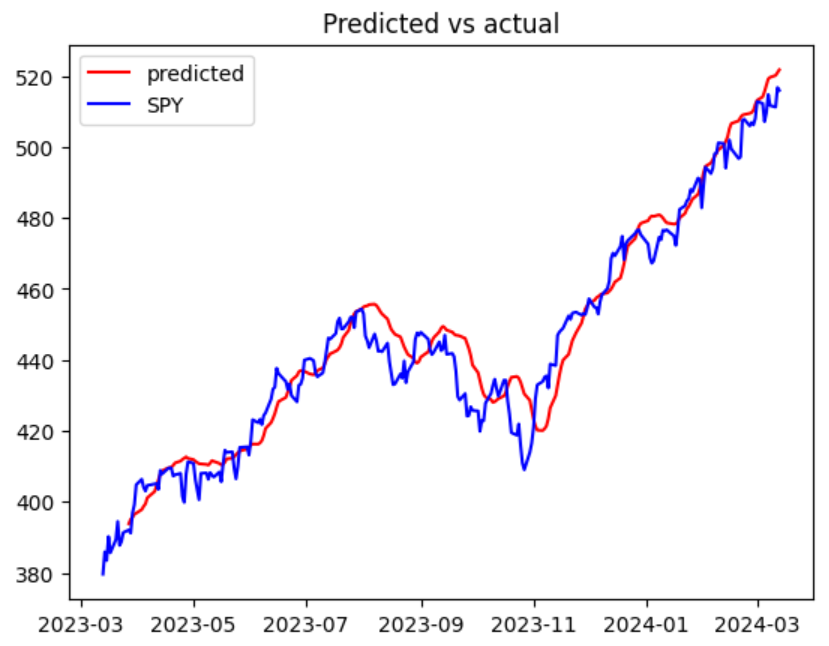

# Part f

## Now try again with a 30 day window.  Do the same code, but change it to a 30 day instead of 10 day window.  Use the same model configuration, compiler and fit.

In [10]:
# Build 30-day sequences from the same scaled series
X_train_30 = []
y_train_30 = []

for i in range(30, len(train)):
    X_train_30.append(train[i-30:i, 0])
    y_train_30.append(train[i, 0])

X_train_30 = np.array(X_train_30)
y_train_30 = np.array(y_train_30)

X_train_30 = np.reshape(
    X_train_30,
    (X_train_30.shape[0], X_train_30.shape[1], 1)
)

# New model for 30-day window
model_30 = Sequential()
model_30.add(
    LSTM(
        50,
        return_sequences=True,
        input_shape=(X_train_30.shape[1], 1)
    )
)
model_30.add(Dropout(0.2))

model_30.add(LSTM(50, return_sequences=True))
model_30.add(Dropout(0.2))

model_30.add(LSTM(50, return_sequences=True))
model_30.add(Dropout(0.2))

model_30.add(LSTM(50))
model_30.add(Dropout(0.2))

model_30.add(Dense(1))

model_30.compile(optimizer="adam", loss="mean_squared_error")

model_30.summary()

history_30 = model_30.fit(
    X_train_30,
    y_train_30,
    epochs=100,
    batch_size=32,
    verbose=1
)

/Users/magmac/Downloads/.venv/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 30, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 30, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.1501
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0313
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0256
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0210
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0143
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0103
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0098
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0104
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0085
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0099
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0090
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0090
Epoch 13/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0091
Epoch 14/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0082
Epoch 15/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0076
Epoch 16/100
7/7 ━━

## Plot the loss vs epochs for the model

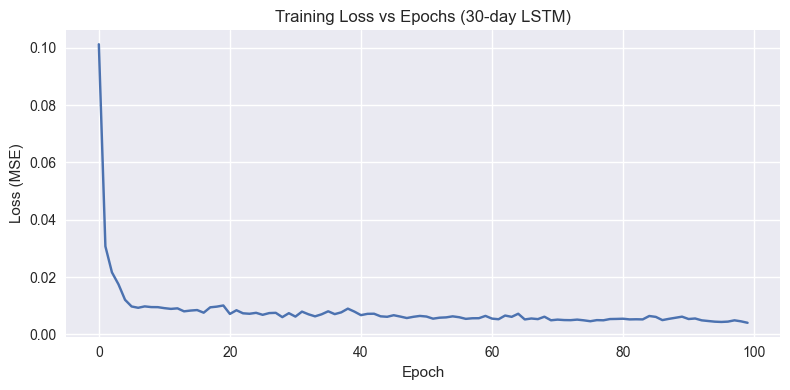

In [18]:
# Training loss vs epochs for 30-day model
plt.figure(figsize=(8, 4))
plt.plot(history_30.history["loss"])
plt.title("Training Loss vs Epochs (30-day LSTM)")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.tight_layout()
plt.show()

# Part g

Plot the same predicted and SPY as above using the 30 day window prediction.  Do you see a difference?

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


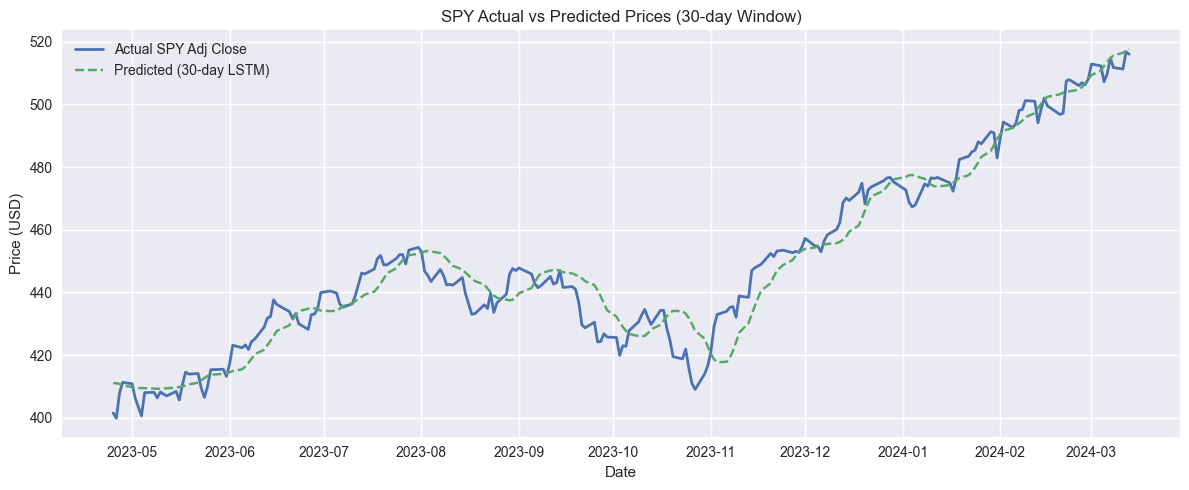

In [19]:
# Predict using 30-day model
predicted_30_scaled = model_30.predict(X_train_30)
predicted_30 = scaler.inverse_transform(predicted_30_scaled)

# Align with data: first prediction corresponds to index 30
dates_30 = df.index[30:]
actual_30 = df["Adj Close"].iloc[30:].values

plt.figure(figsize=(12, 5))
plt.plot(dates_30, actual_30, label="Actual SPY Adj Close", linewidth=2)
plt.plot(dates_30, predicted_30.flatten(), label="Predicted (30-day LSTM)", linestyle="--")
plt.title("SPY Actual vs Predicted Prices (30-day Window)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

### No difference noted.

# Part h

We are going to find all the anomaly days in the stock prices.  An anomaly day will be defined as a day where the mean squared error between the predicted value and actual value is more than three times the average daily mean squared error.

Using the predicted prices from the above 30 day model, calculate the mean squared error for each day and put it in the dataframe as 'mse_loss'.  You can fill the first thirty days with zeros since there is no prediction.  Plot a histogram of the mean squared error for each day and calculate the mean of all the daily mean squared error values (excluding the zeros you added for the first 30 days).

Next, make a column in the dataframe called 'anomaly'.  The value of 'anomaly' will be True if the daily mean squared error is greater than three times the average daily mean squared error.

Finally, plot the Adj Close for SPY with a blue line, the predicted values with a green line, and the anomaly days value with a red point.  Make sure you have a legened and the x-values are the date.  Think about what action you would take with your stock on the anomaly days.

Average MSE (over predicted days): 46.42489423494279
Number of anomaly days: 18


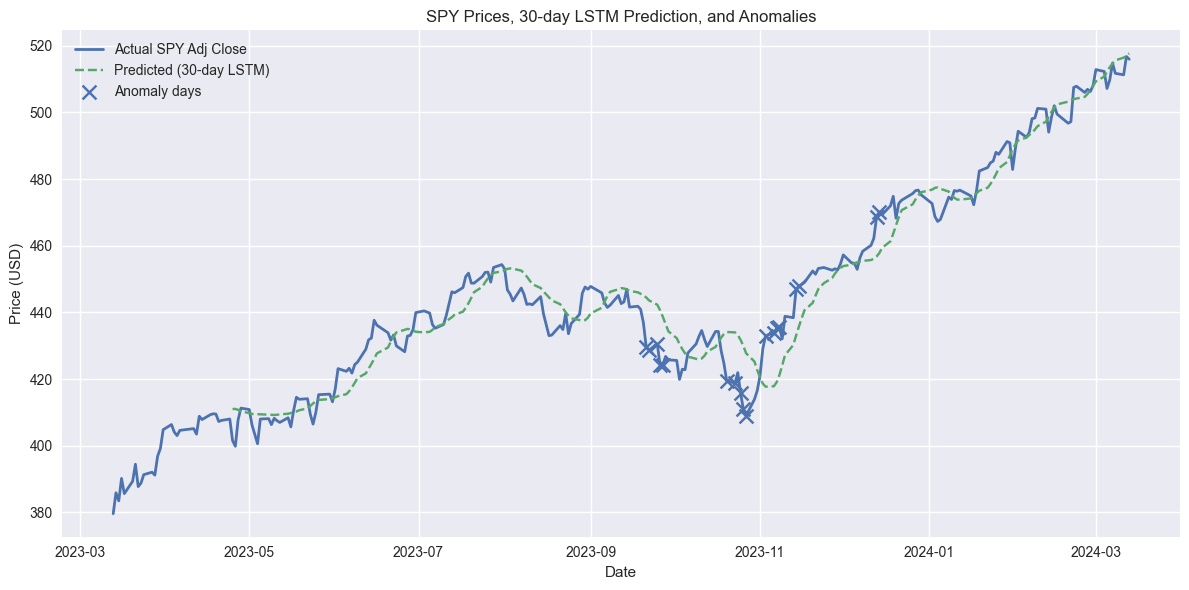

In [20]:
# Start from a clean predicted column aligned with the DataFrame
df["predicted"] = np.nan
df.loc[dates_30, "predicted"] = predicted_30.flatten()

# Daily mean squared error (only where predictions exist)
df["mse"] = (df["Adj Close"] - df["predicted"]) ** 2
# For days without prediction (first 30), set mse to 0
df["mse"] = df["mse"].fillna(0.0)

# Average MSE over days that actually have predictions
avg_mse = df.loc[df["mse"] > 0, "mse"].mean()

# Anomaly if mse > 3 * avg_mse
df["anomaly"] = ((df["mse"] > 3.0 * avg_mse)).astype(int)

print("Average MSE (over predicted days):", avg_mse)
print("Number of anomaly days:", df["anomaly"].sum())

# Plot actual, predicted, and anomalies
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Adj Close"], label="Actual SPY Adj Close", linewidth=2)
plt.plot(df.index, df["predicted"], label="Predicted (30-day LSTM)", linestyle="--")

# Mark anomalies
anomaly_mask = df["anomaly"] == 1
plt.scatter(
    df.index[anomaly_mask],
    df.loc[anomaly_mask, "Adj Close"],
    marker="x",
    s=100,
    label="Anomaly days"
)

plt.title("SPY Prices, 30-day LSTM Prediction, and Anomalies")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

# Part i

Stock traders often look at buying a stock when the current price is below the moving average.  The theory is that it will soon rise back up to the moving average.  Likewise, they sell when the price is above the moving average assuming it will fall back to the average.  You are going to print out 'buy' or 'sell' and the date when the stock price crosses the 30 day prediction prices we calculated above.

Now take the predicted price and add that as a column to the original dataframe with Adj Close and date.  You will have to cut the first 30 days from the original dataframe to make the lengths match.  Then add a column called 'above_below' that is 'Adj Close' minus 'predicted'.

In [21]:
# Difference between actual and predicted
df["above_below"] = df["Adj Close"] - df["predicted"]
df[["Adj Close", "predicted", "above_below"]].tail()

,Adj Close,predicted,above_below
Date,,,
2024-03-07,514.809998,514.663269,0.146729
2024-03-08,511.720001,515.616394,-3.896393
2024-03-11,511.279999,516.426880,-5.146881
2024-03-12,516.780029,517.072876,-0.292847
2024-03-13,515.969971,517.698914,-1.728943


Create a new column that shows if the difference is positive (+1) and negative one if the difference is a negative number or zero.  Call that column 'diff'.  When you are done, the 'diff' column will only contain +1 or -1 values.

Now create a column called 'action'.  That will have 'sell' if 'diff' is one and 'buy' if diff is negative one.

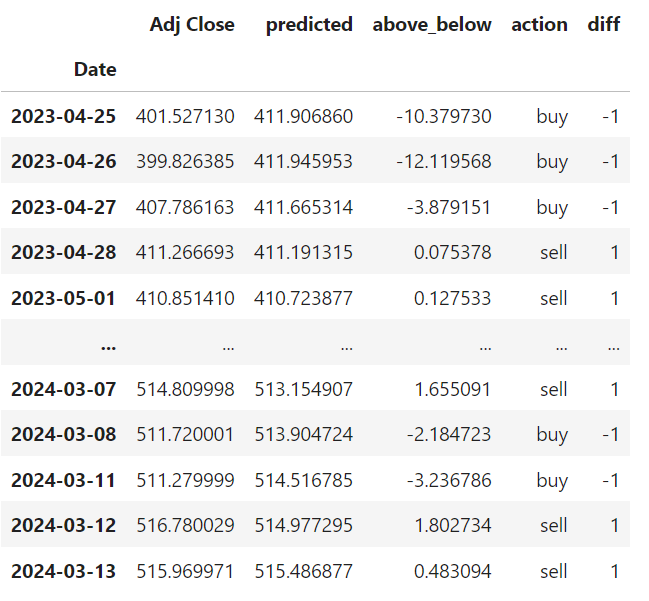

In [22]:
# +1 if actual above predicted, -1 if actual below predicted
df["diff"] = np.where(df["above_below"] > 0, 1, -1)
df["action"] = np.where(df["diff"] > 0, "sell", "buy")
df[["Adj Close", "predicted", "above_below", "diff", "action"]].tail()

,Adj Close,predicted,above_below,diff,action
Date,,,,,
2024-03-07,514.809998,514.663269,0.146729,1,sell
2024-03-08,511.720001,515.616394,-3.896393,-1,buy
2024-03-11,511.279999,516.426880,-5.146881,-1,buy
2024-03-12,516.780029,517.072876,-0.292847,-1,buy
2024-03-13,515.969971,517.698914,-1.728943,-1,buy


# Part j

The pandas diff() method will show you the difference between the current row and the row above.  The line of code below will print the dataframe index values (which are now the Date) for each time the 'above_below' changes from +1 to -1 or from -1 to +1.

print(df['diff'].diff()[df['diff'].diff() != 0].index.values)

In [23]:
# Indexes where diff changes sign
diff_change = df["diff"].diff()
# Locations where sign changes (non-zero difference)
crossing_index = diff_change[diff_change != 0].index.values
print("Indices where diff changes sign (crossing points):")
print(crossing_index)

Indices where diff changes sign (crossing points):
['2023-03-13T00:00:00.000000000' '2023-04-28T00:00:00.000000000'
 '2023-05-02T00:00:00.000000000' '2023-05-17T00:00:00.000000000'
 '2023-05-23T00:00:00.000000000' '2023-05-26T00:00:00.000000000'
 '2023-05-31T00:00:00.000000000' '2023-06-01T00:00:00.000000000'
 '2023-06-23T00:00:00.000000000' '2023-06-29T00:00:00.000000000'
 '2023-07-07T00:00:00.000000000' '2023-07-11T00:00:00.000000000'
 '2023-07-27T00:00:00.000000000' '2023-07-28T00:00:00.000000000'
 '2023-08-02T00:00:00.000000000' '2023-08-28T00:00:00.000000000'
 '2023-09-06T00:00:00.000000000' '2023-09-14T00:00:00.000000000'
 '2023-09-15T00:00:00.000000000' '2023-10-06T00:00:00.000000000'
 '2023-10-18T00:00:00.000000000' '2023-11-01T00:00:00.000000000'
 '2023-12-06T00:00:00.000000000' '2023-12-07T00:00:00.000000000'
 '2023-12-29T00:00:00.000000000' '2024-01-10T00:00:00.000000000'
 '2024-01-17T00:00:00.000000000' '2024-01-18T00:00:00.000000000'
 '2024-01-31T00:00:00.000000000' '2024-

Now use those date indexes to print the dates where the predicted moves below the current price (in this case print 'buy').  When the predicted price goes above the current price, then print the date and 'sell'.  

In [24]:
# Print dates and actions at crossing points
diff_change = df["diff"].diff()
crossing_dates = diff_change[diff_change != 0].index

print("Buy/Sell signals at crossings of price and predicted value:")
for date in crossing_dates:
    # action at that date (based on diff sign *after* the change)
    action = df.loc[date, "action"]
    # Format date nicely
    print(date.date(), action)

Buy/Sell signals at crossings of price and predicted value:
2023-03-13 buy
2023-04-28 sell
2023-05-02 buy
2023-05-17 sell
2023-05-23 buy
2023-05-26 sell
2023-05-31 buy
2023-06-01 sell
2023-06-23 buy
2023-06-29 sell
2023-07-07 buy
2023-07-11 sell
2023-07-27 buy
2023-07-28 sell
2023-08-02 buy
2023-08-28 sell
2023-09-06 buy
2023-09-14 sell
2023-09-15 buy
2023-10-06 sell
2023-10-18 buy
2023-11-01 sell
2023-12-06 buy
2023-12-07 sell
2023-12-29 buy
2024-01-10 sell
2024-01-17 buy
2024-01-18 sell
2024-01-31 buy
2024-02-02 sell
2024-02-13 buy
2024-02-15 sell
2024-02-16 buy
2024-02-22 sell
2024-02-28 buy
2024-02-29 sell
2024-03-05 buy
2024-03-07 sell
2024-03-08 buy
